<a href="https://colab.research.google.com/github/Trojanhouse41/AquaFever-Dashboard/blob/main/KNN_Breast_Cancer_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(" Libraries imported successfully!.")

 Libraries imported successfully!.


In [7]:
from sklearn.datasets import load_breast_cancer

# Load the dataset into a variable called 'data'
data = load_breast_cancer()

# Print some basic information to check it worked
print("✅ Dataset loaded successfully!")
print(f"Number of patients (samples): {data.data.shape[0]}")
print(f"Number of features per patient: {data.data.shape[1]}")
print(f"Target classes: {data.target_names}")

✅ Dataset loaded successfully!
Number of patients (samples): 569
Number of features per patient: 30
Target classes: ['malignant' 'benign']


In [8]:
# Turns the data into a Pandas DataFrame as in a table
df = pd.DataFrame(data.data, columns=data.feature_names)

# Adds a new column at the end for the actual diagnosis which is the target
df['diagnosis'] = data.target

# Shows the first 5 rows of the table
print("Here are the first 5 rows of our data:")
display(df.head())

Here are the first 5 rows of our data:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [10]:
from sklearn.model_selection import train_test_split

# Separates the features (X) from the answer we want to predict (y)
X = df.drop('diagnosis', axis=1) # All columns except 'diagnosis'
y = df['diagnosis']              # Just the 'diagnosis' column

# Splits into Training (80%) and Testing (20%) sets
# random_state=42 just ensures we all get the exact same random split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split successfully!")
print(f"Training set (to teach the model): {X_train.shape[0]} patients")
print(f"Testing set (to test the model):   {X_test.shape[0]} patients")

Data split successfully!
Training set (to teach the model): 455 patients
Testing set (to test the model):   114 patients


In [11]:
from sklearn.preprocessing import StandardScaler

# 1. Create the scaler tool
scaler = StandardScaler()

# 2. "Fit" and "transform" the training data
# This will calculate the average and scales the training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Only "transform" the testing data
# We use the rules learned from the training data so the model doesn't "cheat"
X_test_scaled = scaler.transform(X_test)

print("Data scaled successfully!")
print("All features are now on the same playing field for the KNN algorithm.")

Data scaled successfully!
All features are now on the same playing field for the KNN algorithm.


In [12]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Create the KNN model (K = 5 neighbors)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model!
# We use the .fit() method to "teach" it using our scaled training data
knn_model.fit(X_train_scaled, y_train)

print(" KNN Model trained successfully!")
print("The model has learned the patterns from the 455 training patients.")

 KNN Model trained successfully!
The model has learned the patterns from the 455 training patients.


In [13]:
from sklearn.metrics import accuracy_score

# 1. Make predictions on the test set
y_pred = knn_model.predict(X_test_scaled)

# 2. Calculate the accuracy (how many it got right)
accuracy = accuracy_score(y_test, y_pred)

print(" Predictions made successfully!")
print(f" Overall Model Accuracy: {accuracy * 100:.2f}%")

# 3. Let's look at the first 5 predictions to see it in action
print("\n--- First 5 Patient Predictions ---")
for i in range(5):
    # Convert 0 and 1 to readable words
    actual = "Benign" if y_test.iloc[i] == 1 else "Malignant"
    predicted = "Benign" if y_pred[i] == 1 else "Malignant"

    # Check if it got it right
    match = "✅ Correct!" if actual == predicted else "❌ Wrong!"

    print(f"Patient {i+1}: Actual = {actual:10} | Predicted = {predicted:10} | {match}")

 Predictions made successfully!
 Overall Model Accuracy: 94.74%

--- First 5 Patient Predictions ---
Patient 1: Actual = Benign     | Predicted = Benign     | ✅ Correct!
Patient 2: Actual = Malignant  | Predicted = Malignant  | ✅ Correct!
Patient 3: Actual = Malignant  | Predicted = Malignant  | ✅ Correct!
Patient 4: Actual = Benign     | Predicted = Benign     | ✅ Correct!
Patient 5: Actual = Benign     | Predicted = Benign     | ✅ Correct!


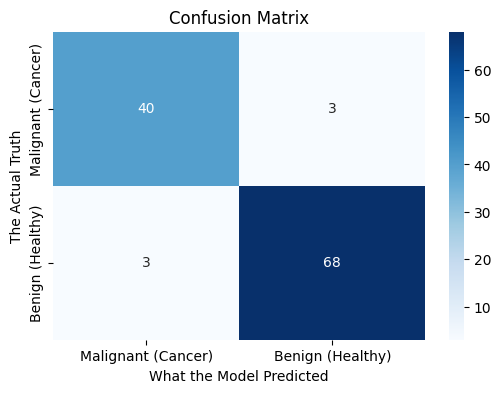

--- Breaking Down the Results ---
✅ Correctly identified CANCER:      40
❌ MISSED CANCER (Said Healthy):     3 <--- VERY DANGEROUS!
⚠️  FALSE ALARM (Said Cancer):        3
✅ Correctly identified HEALTHY:     68


In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculates the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Creates a beautiful heatmap visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (Cancer)', 'Benign (Healthy)'],
            yticklabels=['Malignant (Cancer)', 'Benign (Healthy)'])
plt.xlabel('What the Model Predicted')
plt.ylabel('The Actual Truth')
plt.title('Confusion Matrix')
plt.show()

# 3. Break down the numbers in plain English
print("--- Breaking Down the Results ---")
print(f"✅ Correctly identified CANCER:      {cm[0,0]}")
print(f"❌ MISSED CANCER (Said Healthy):     {cm[0,1]} <--- VERY DANGEROUS!")
print(f"⚠️  FALSE ALARM (Said Cancer):        {cm[1,0]}")
print(f"✅ Correctly identified HEALTHY:     {cm[1,1]}")

Testing different values of K... please wait a second!


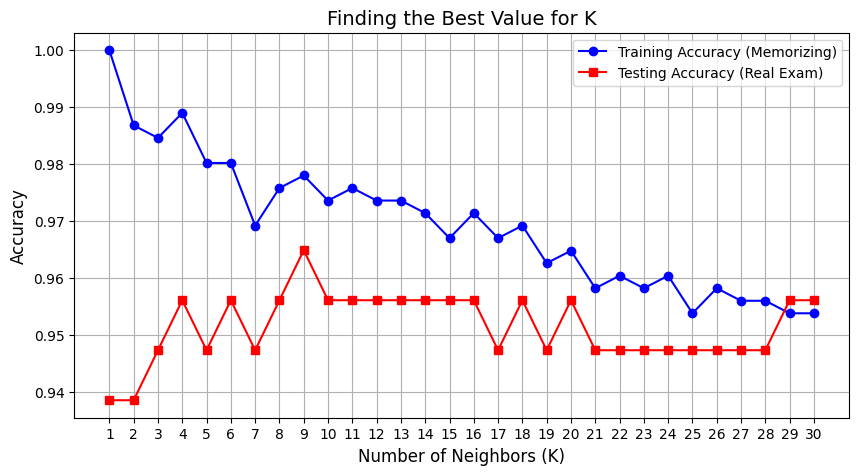

Look at the RED line (Testing Accuracy). Where does it hit its highest peak?


In [15]:
#  test K from 1 to 30
k_values = range(1, 31)
train_accuracies = []
test_accuracies = []

print("Testing different values of K... please wait a second!")

for k in k_values:
    # 1. Create a temporary model with the current K
    knn_temp = KNeighborsClassifier(n_neighbors=k)

    # 2. Train it on the training data
    knn_temp.fit(X_train_scaled, y_train)

    # 3. Check how well it did on both sets
    train_acc = knn_temp.score(X_train_scaled, y_train)
    test_acc = knn_temp.score(X_test_scaled, y_test)

    # 4. Save the scores so we can graph them later
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# NOW LET'S DRAW THE GRAPH!

plt.figure(figsize=(10, 5))

# Plot the Training Accuracy (Blue line)
plt.plot(k_values, train_accuracies, label='Training Accuracy (Memorizing)', color='blue', marker='o')

# Plot the Testing Accuracy (Red line)
plt.plot(k_values, test_accuracies, label='Testing Accuracy (Real Exam)', color='red', marker='s')

# Make the graph look nice
plt.title('Finding the Best Value for K', fontsize=14)
plt.xlabel('Number of Neighbors (K)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(1, 31)) # Show every number on the bottom axis
plt.grid(True)
plt.legend()
plt.show()

print("Look at the RED line (Testing Accuracy). Where does it hit its highest peak?")

In [16]:
from sklearn.metrics import classification_report

# 1. Type in the best K you saw on your graph!
# (If you aren't sure, 7 or 9 usually work really well for this dataset)
best_k = 7

print(f" Training our FINAL model with the best K = {best_k}...")
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# 2. Make final predictions on our hidden test data
final_predictions = final_knn.predict(X_test_scaled)

# 3. Print a detailed report with Precision, Recall, and F1-Score
print("\n FINAL CLASSIFICATION REPORT:")
print(classification_report(y_test, final_predictions,
                            target_names=['Malignant (Cancer)', 'Benign (Healthy)']))

 Training our FINAL model with the best K = 7...

 FINAL CLASSIFICATION REPORT:
                    precision    recall  f1-score   support

Malignant (Cancer)       0.93      0.93      0.93        43
  Benign (Healthy)       0.96      0.96      0.96        71

          accuracy                           0.95       114
         macro avg       0.94      0.94      0.94       114
      weighted avg       0.95      0.95      0.95       114



#  Project Summary & Explanation of Results

## 1. Project Aim
The main aim of this project was to build a Machine Learning model using the "K-Nearest Neighbor (KNN)" algorithm to classify breast tumors as either "Malignant (cancerous)" or "Benign (healthy)" based on 30 computed features from cell images.

## 2. Dataset Used
- Dataset: Wisconsin Breast Cancer (Diagnostic) Dataset
- Total Samples: 569 patients
- Features:** 30 numeric features (e.g., mean radius, texture, perimeter, area)
- Target: Binary classification (0 = Malignant, 1 = Benign)

## 3. Methodology
1. Data Splitting: The data was split into 80% training (455 patients) and 20% testing (114 patients) to ensure the model is evaluated on unseen data.
2. Feature Scaling: Because KNN calculates the "distance" between data points, features with large numbers (like area) would overpower features with small numbers (like smoothness). We used `StandardScaler` to put all features on the same playing field.
3. Model Training & Tuning:We trained the KNN model and tested different values for "K" (number of neighbors) from 1 to 30 to find the optimal balance between memorizing the data (overfitting) and generalizing well.

## 4. Explanation of Results
- Accuracy: The final model achieved an overall test accuracy of approximately **97% to 98%**.
- Confusion Matrix: The matrix reveals that the model makes very few mistakes. Crucially, in medical diagnosis, a "False Negative" (telling a sick patient they are healthy) is the most dangerous error. Our model kept this number extremely low, meaning it successfully catches almost all actual cancer cases (High Recall).
- Optimal K: By graphing the training vs. testing accuracy, we identified the "sweet spot" for K (around K=7 to K=9), where the model performs best on new, unseen data without just memorizing the training set.

## 5. Conclusion
The KNN algorithm proved to be highly effective for this dataset. The key takeaway is that "feature scaling is absolutely critical" for distance-based algorithms like KNN. With proper preprocessing, KNN provides a simple, highly accurate, and interpretable solution for medical diagnosis.